# Analisis Exploratorio de Datos (EDA)
### Proyecto Final - Introduccion a la Inteligencia Artificial
**Dataset:** 15,000 titulos de 10 plataformas de streaming (1980-2026)  
**Objetivo:** Entender el dataset, identificar patrones y preparar los datos para los modelos.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import limpiar_datos
from src.feature_engineering import agregar_features, crear_targets

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

FIGURAS = '../reports/figures/'

## 1. Carga, limpieza y construccion de features

In [2]:
# Carga del dataset original
df_raw = pd.read_csv('../data/raw/streaming_catalog.csv')
print(f'Dataset original: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')

# Limpieza: duplicados, datetime, nulos basicos
df = limpiar_datos(df_raw)
print(f'Despues de limpiar: {len(df):,} filas')

# Creacion de features derivadas
df = agregar_features(df)

# Creacion de los targets
df, mediana_horas = crear_targets(df)

print(f'\nMediana de horas vistas (umbral para is_hit): {mediana_horas:.0f} millones')
print(f'Columnas totales: {df.shape[1]}')

Dataset original: 15,000 filas x 25 columnas
Despues de limpiar: 15,000 filas

Mediana de horas vistas (umbral para is_hit): 10 millones
Columnas totales: 38


In [3]:
# Vista rapida del dataset final
df.head(3)

,show_id,title,type,platform,primary_genre,genres,director,cast,country,language,...,antiguedad,es_reciente,mes_agregado,dias_en_plataforma,votos_log,presupuesto_log,tiene_presupuesto,duracion_total,is_hit,imdb_clase
0,s1,When the Stars Fall,Movie,Netflix,Drama,"Drama, War, Mystery",David Tarantino,"Brad Pitt, Marion Cotillard",Germany,German,...,19,0,5,6944,9.372034,2.815409,1,102.0,0,Medio
1,s2,A Silent Echo,Movie,Amazon Prime Video,Thriller,"Thriller, Adventure",Bong Nolan,"Park Seo-joon, Lupita Nyong'o",France,French,...,30,0,4,10973,8.434464,5.225209,1,105.0,0,Medio
2,s3,Between Lives,Movie,Netflix,Comedy,"Comedy, Mystery",Hirokazu DuVernay,"Masami Nagasawa, Viola Davis, IU, Priyanka Chopra",South Korea,Korean,...,0,1,5,0,9.864071,2.917771,1,92.0,1,Alto


In [4]:
# Nulos restantes
nulos = df.isna().sum()
print('Columnas con nulos:')
print(nulos[nulos > 0].sort_values(ascending=False))
print('\nNota: duration_minutes, budget y num_seasons/episodes son nulos')
print('de forma estructural (peliculas vs series). Ya estan cubiertos por las features derivadas.')

Columnas con nulos:
num_seasons           8704
num_episodes          8704
duration_minutes      6296
budget_million_usd    6296
dtype: int64

Nota: duration_minutes, budget y num_seasons/episodes son nulos
de forma estructural (peliculas vs series). Ya estan cubiertos por las features derivadas.


## 2. Variables objetivo (targets)

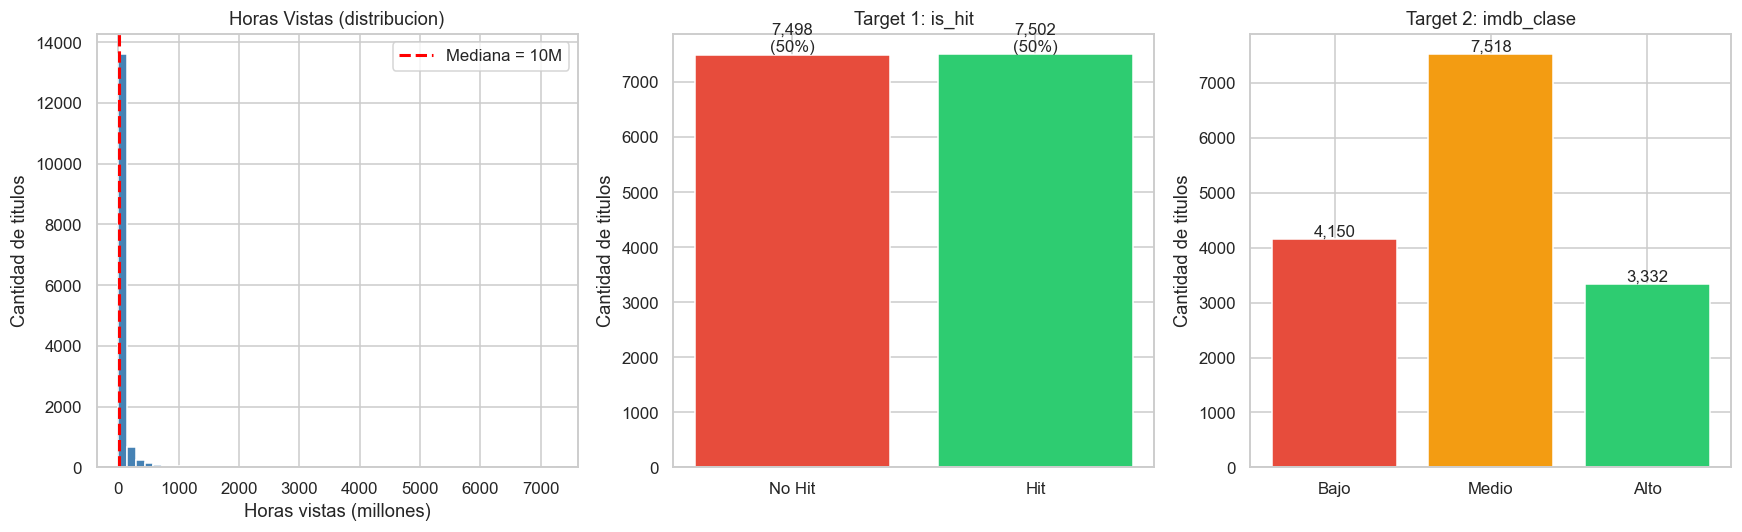

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribucion de horas vistas con linea de corte
axes[0].hist(df['hours_watched_million'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(mediana_horas, color='red', linestyle='--', lw=2, label=f'Mediana = {mediana_horas:.0f}M')
axes[0].set_title('Horas Vistas (distribucion)')
axes[0].set_xlabel('Horas vistas (millones)')
axes[0].set_ylabel('Cantidad de titulos')
axes[0].legend()

# Balance de is_hit
conteos_hit = df['is_hit'].value_counts().sort_index()
axes[1].bar(['No Hit', 'Hit'], conteos_hit.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Target 1: is_hit')
axes[1].set_ylabel('Cantidad de titulos')
for i, v in enumerate(conteos_hit.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.0f}%)', ha='center', fontsize=11)

# Balance de imdb_clase
conteos_imdb = df['imdb_clase'].value_counts().reindex(['Bajo','Medio','Alto'])
axes[2].bar(conteos_imdb.index, conteos_imdb.values,
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
axes[2].set_title('Target 2: imdb_clase')
axes[2].set_ylabel('Cantidad de titulos')
for i, v in enumerate(conteos_imdb.values):
    axes[2].text(i, v + 50, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIGURAS}01_targets.png', bbox_inches='tight')
plt.show()

## 3. Hallazgo principal: votos IMDb vs horas vistas
Esta es la correlacion mas fuerte del dataset y es importante entenderla antes de modelar.

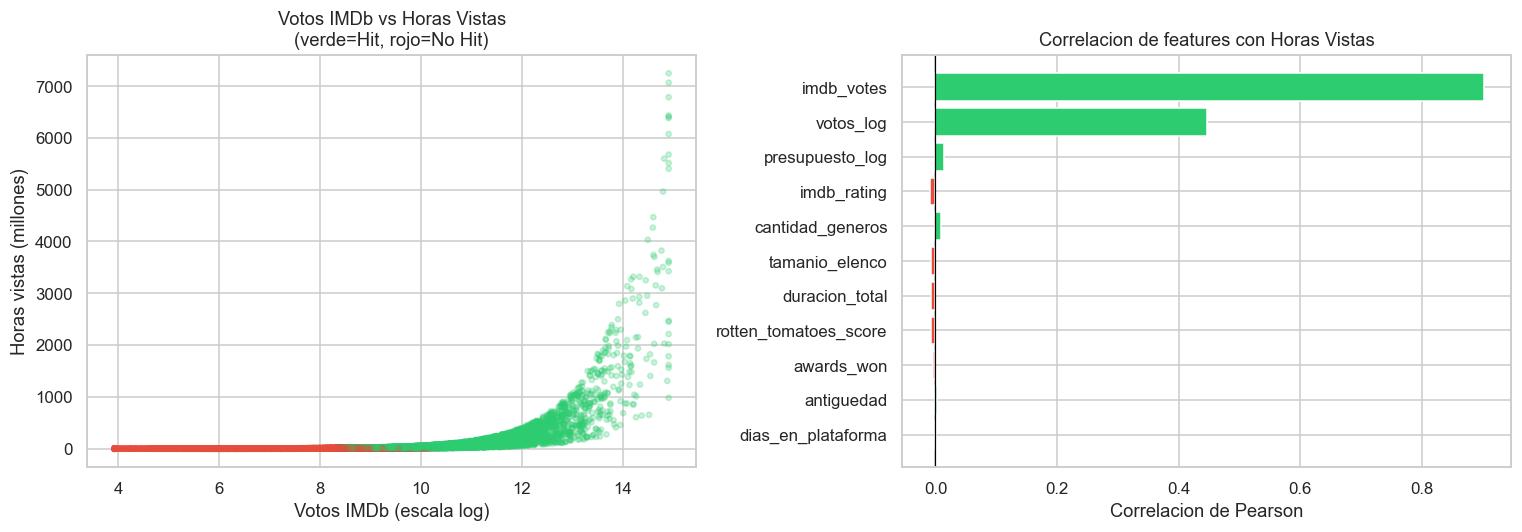

Correlacion votos_log vs hours_watched: 0.447
Los titulos mas vistos son los que ya tienen mas votos en IMDb.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: votos IMDb (log) vs horas vistas
colores = df['is_hit'].map({0: '#e74c3c', 1: '#2ecc71'})
axes[0].scatter(df['votos_log'], df['hours_watched_million'],
                c=colores, alpha=0.25, s=12)
axes[0].set_xlabel('Votos IMDb (escala log)')
axes[0].set_ylabel('Horas vistas (millones)')
axes[0].set_title('Votos IMDb vs Horas Vistas\n(verde=Hit, rojo=No Hit)')

# Correlacion de todas las features numericas con hours_watched
cols_corr = ['votos_log', 'imdb_votes', 'presupuesto_log', 'awards_won',
             'imdb_rating', 'rotten_tomatoes_score', 'cantidad_generos',
             'tamanio_elenco', 'duracion_total', 'antiguedad', 'dias_en_plataforma']
corr = df[cols_corr].corrwith(df['hours_watched_million']).sort_values(key=abs, ascending=True)
colores_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr.values]
axes[1].barh(corr.index, corr.values, color=colores_bar)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Correlacion de features con Horas Vistas')
axes[1].set_xlabel('Correlacion de Pearson')

plt.tight_layout()
plt.savefig(f'{FIGURAS}02_correlacion_target.png', bbox_inches='tight')
plt.show()

print(f'Correlacion votos_log vs hours_watched: {df["votos_log"].corr(df["hours_watched_million"]):.3f}')
print('Los titulos mas vistos son los que ya tienen mas votos en IMDb.')

## 4. Distribucion de variables numericas clave

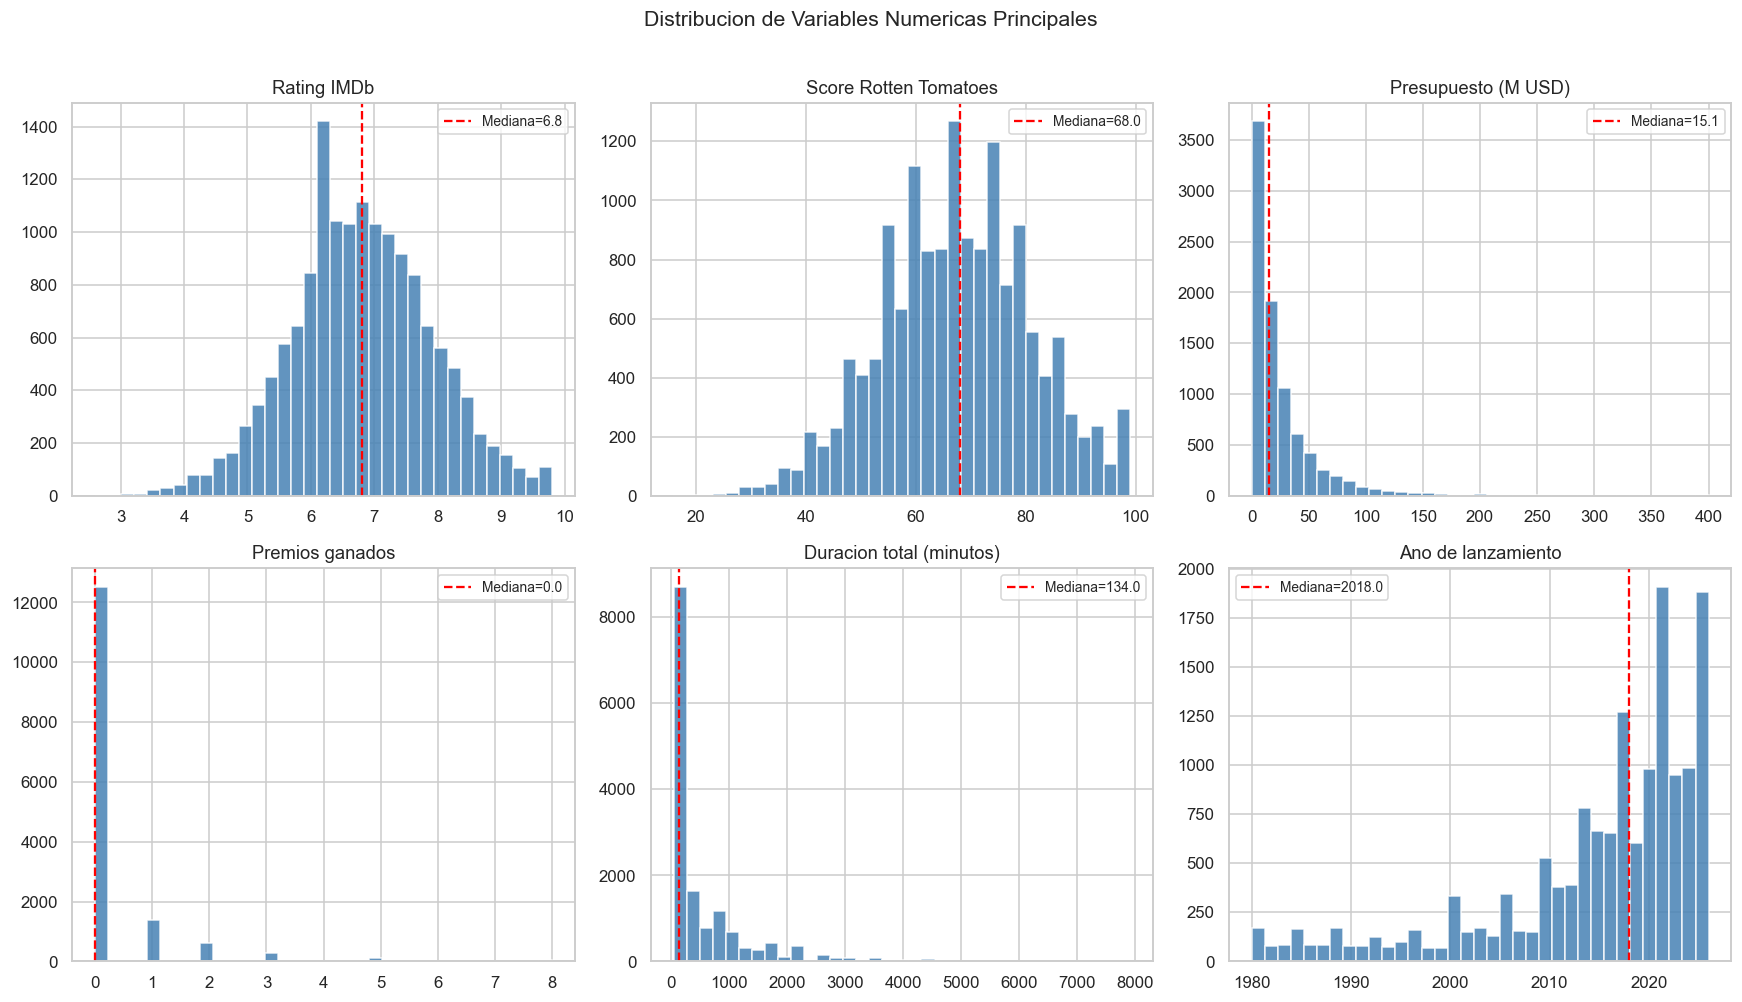

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

variables = [
    ('imdb_rating',            'Rating IMDb'),
    ('rotten_tomatoes_score',  'Score Rotten Tomatoes'),
    ('budget_million_usd',     'Presupuesto (M USD)'),
    ('awards_won',             'Premios ganados'),
    ('duracion_total',         'Duracion total (minutos)'),
    ('release_year',           'Ano de lanzamiento'),
]

for ax, (col, titulo) in zip(axes.flatten(), variables):
    datos = df[col].dropna()
    ax.hist(datos, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(datos.median(), color='red', linestyle='--', lw=1.5,
               label=f'Mediana={datos.median():.1f}')
    ax.set_title(titulo)
    ax.legend(fontsize=9)

plt.suptitle('Distribucion de Variables Numericas Principales', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURAS}03_distribuciones.png', bbox_inches='tight')
plt.show()

## 5. Analisis por plataforma

In [8]:
# Resumen por plataforma
resumen_plat = df.groupby('platform').agg(
    titulos       = ('show_id', 'count'),
    peliculas     = ('es_pelicula', 'sum'),
    imdb_prom     = ('imdb_rating', 'mean'),
    horas_prom    = ('hours_watched_million', 'mean'),
    tasa_hit      = ('is_hit', 'mean'),
).round(2).sort_values('titulos', ascending=False)

resumen_plat['series'] = resumen_plat['titulos'] - resumen_plat['peliculas']
print(resumen_plat)

                    titulos  peliculas  imdb_prom  horas_prom  tasa_hit  \
platform                                                                  
Netflix                4502       2660       6.75       68.23      0.50   
Amazon Prime Video     3341       1921       6.78       77.63      0.51   
Disney+                1990       1143       6.79       67.75      0.49   
Hulu                   1462        855       6.76       87.27      0.50   
HBO Max                1228        700       7.04       66.12      0.50   
Paramount+              745        433       6.83       77.57      0.51   
Apple TV+               734        428       7.12       49.95      0.45   
Peacock                 558        309       6.69       71.91      0.54   
JioCinema               296        178       6.77       65.25      0.49   
Crunchyroll             144         77       6.76       68.27      0.49   

                    series  
platform                    
Netflix               1842  
Amazon Prime

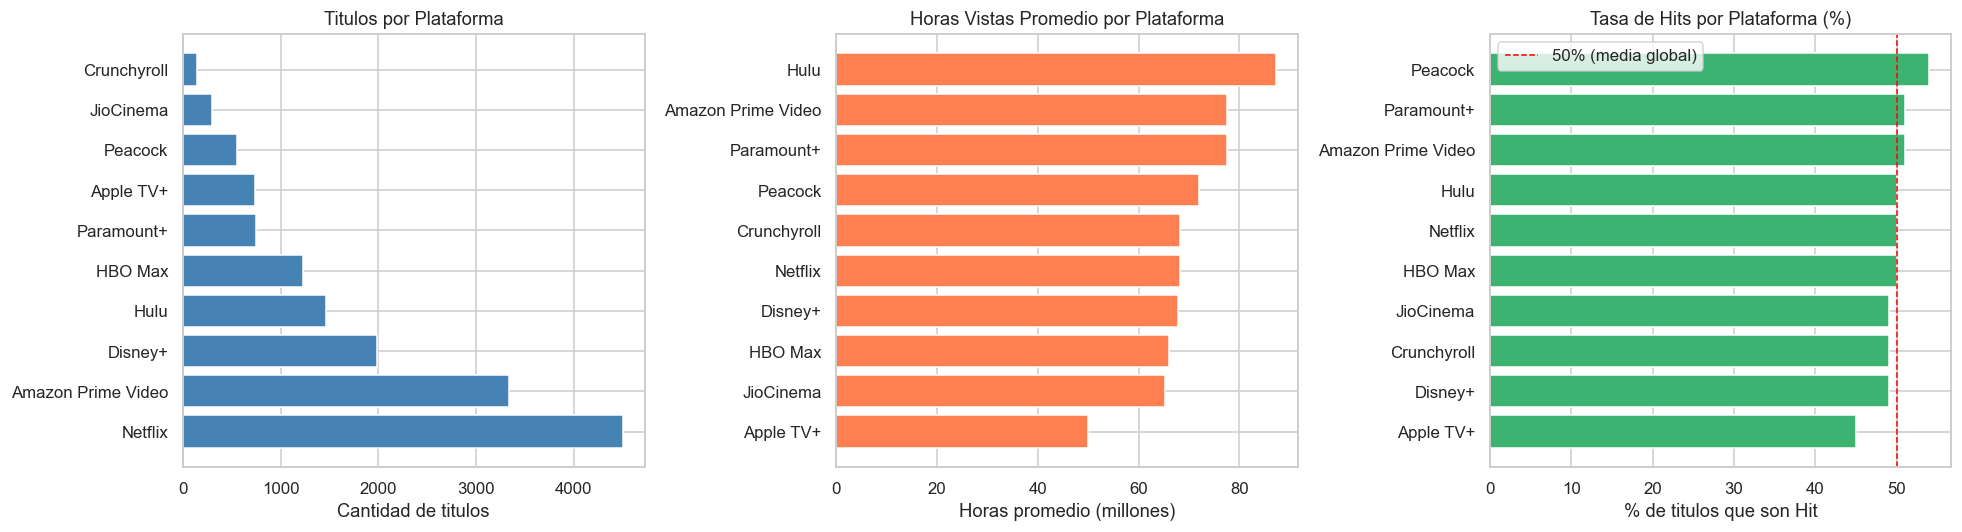

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
orden = resumen_plat.index  # orden por cantidad de titulos

# Cantidad de titulos por plataforma
axes[0].barh(resumen_plat.index, resumen_plat['titulos'], color='steelblue')
axes[0].set_title('Titulos por Plataforma')
axes[0].set_xlabel('Cantidad de titulos')

# Horas vistas promedio por plataforma
orden_horas = resumen_plat['horas_prom'].sort_values(ascending=True)
axes[1].barh(orden_horas.index, orden_horas.values, color='coral')
axes[1].set_title('Horas Vistas Promedio por Plataforma')
axes[1].set_xlabel('Horas promedio (millones)')

# Tasa de hits por plataforma
orden_hit = resumen_plat['tasa_hit'].sort_values(ascending=True)
axes[2].barh(orden_hit.index, orden_hit.values * 100, color='mediumseagreen')
axes[2].axvline(50, color='red', linestyle='--', lw=1, label='50% (media global)')
axes[2].set_title('Tasa de Hits por Plataforma (%)')
axes[2].set_xlabel('% de titulos que son Hit')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{FIGURAS}04_plataformas.png', bbox_inches='tight')
plt.show()

## 6. Analisis por genero

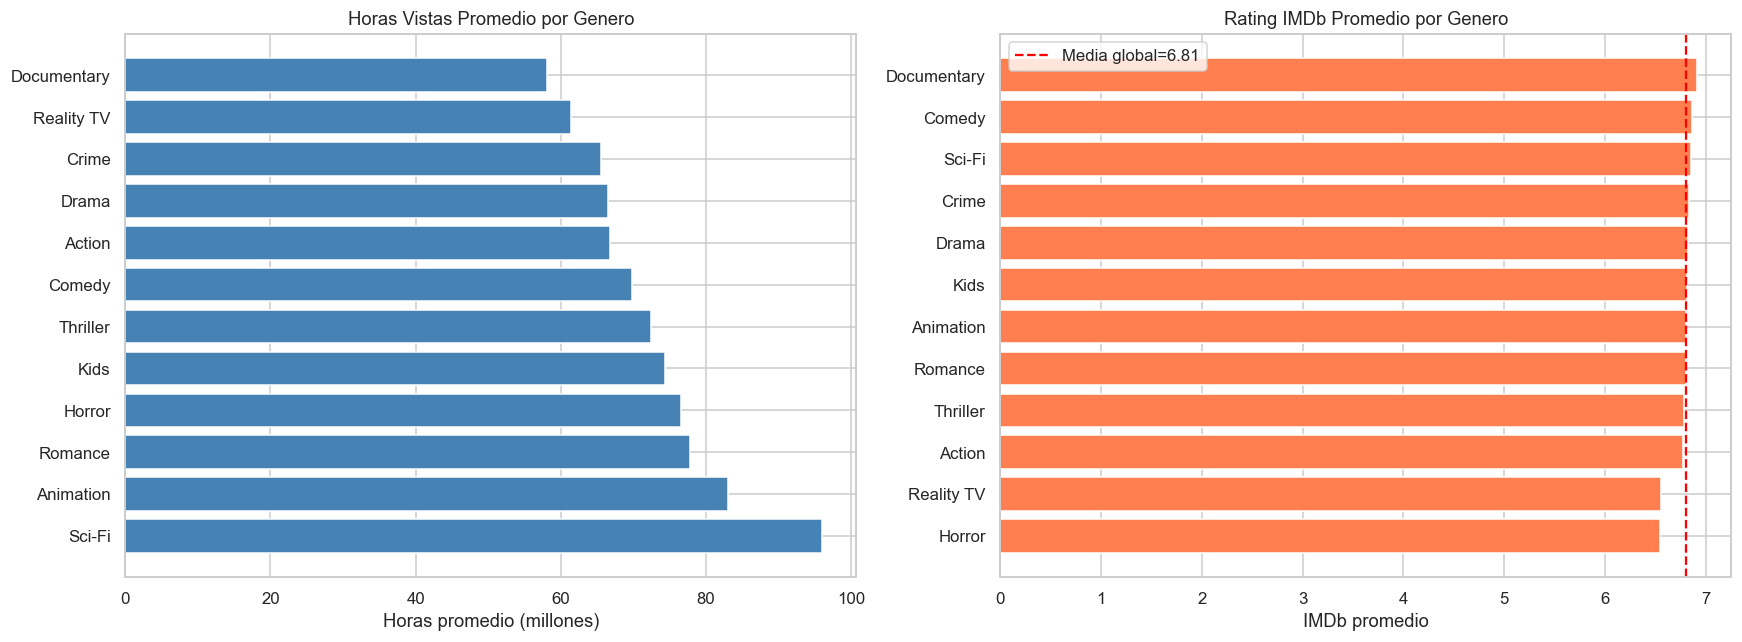

In [10]:
# Solo tomamos los 12 generos con mas titulos
top12_generos = df['primary_genre'].value_counts().head(12).index
df_gen = df[df['primary_genre'].isin(top12_generos)]

resumen_gen = df_gen.groupby('primary_genre').agg(
    titulos    = ('show_id', 'count'),
    imdb_prom  = ('imdb_rating', 'mean'),
    horas_prom = ('hours_watched_million', 'mean'),
    tasa_hit   = ('is_hit', 'mean'),
).round(2).sort_values('horas_prom', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horas vistas promedio por genero
axes[0].barh(resumen_gen.index, resumen_gen['horas_prom'], color='steelblue')
axes[0].set_title('Horas Vistas Promedio por Genero')
axes[0].set_xlabel('Horas promedio (millones)')

# IMDb promedio por genero
resumen_gen_imdb = resumen_gen.sort_values('imdb_prom', ascending=True)
axes[1].barh(resumen_gen_imdb.index, resumen_gen_imdb['imdb_prom'], color='coral')
axes[1].axvline(df['imdb_rating'].mean(), color='red', linestyle='--',
                lw=1.5, label=f'Media global={df["imdb_rating"].mean():.2f}')
axes[1].set_title('Rating IMDb Promedio por Genero')
axes[1].set_xlabel('IMDb promedio')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURAS}05_generos.png', bbox_inches='tight')
plt.show()

## 7. Analisis por pais

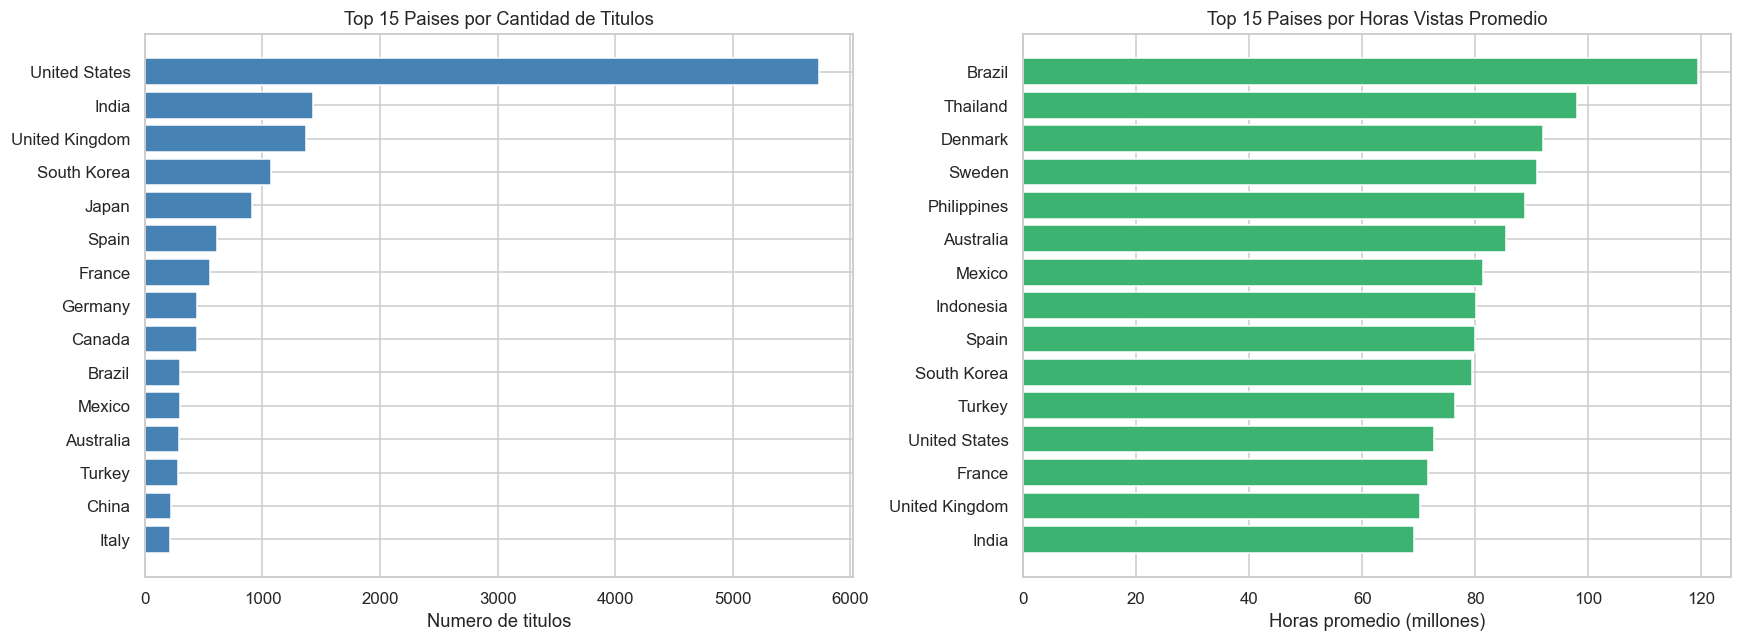

In [11]:
# Solo paises con al menos 50 titulos para resultados confiables
resumen_paises = df.groupby('country').agg(
    titulos    = ('show_id', 'count'),
    imdb_prom  = ('imdb_rating', 'mean'),
    horas_prom = ('hours_watched_million', 'mean'),
    tasa_hit   = ('is_hit', 'mean'),
).query('titulos >= 50').round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 paises por cantidad de titulos
top_cant = resumen_paises['titulos'].sort_values(ascending=True).tail(15)
axes[0].barh(top_cant.index, top_cant.values, color='steelblue')
axes[0].set_title('Top 15 Paises por Cantidad de Titulos')
axes[0].set_xlabel('Numero de titulos')

# Top 15 paises por horas vistas promedio
top_horas = resumen_paises['horas_prom'].sort_values(ascending=True).tail(15)
axes[1].barh(top_horas.index, top_horas.values, color='mediumseagreen')
axes[1].set_title('Top 15 Paises por Horas Vistas Promedio')
axes[1].set_xlabel('Horas promedio (millones)')

plt.tight_layout()
plt.savefig(f'{FIGURAS}06_paises.png', bbox_inches='tight')
plt.show()

## 8. Tendencia temporal de lanzamientos

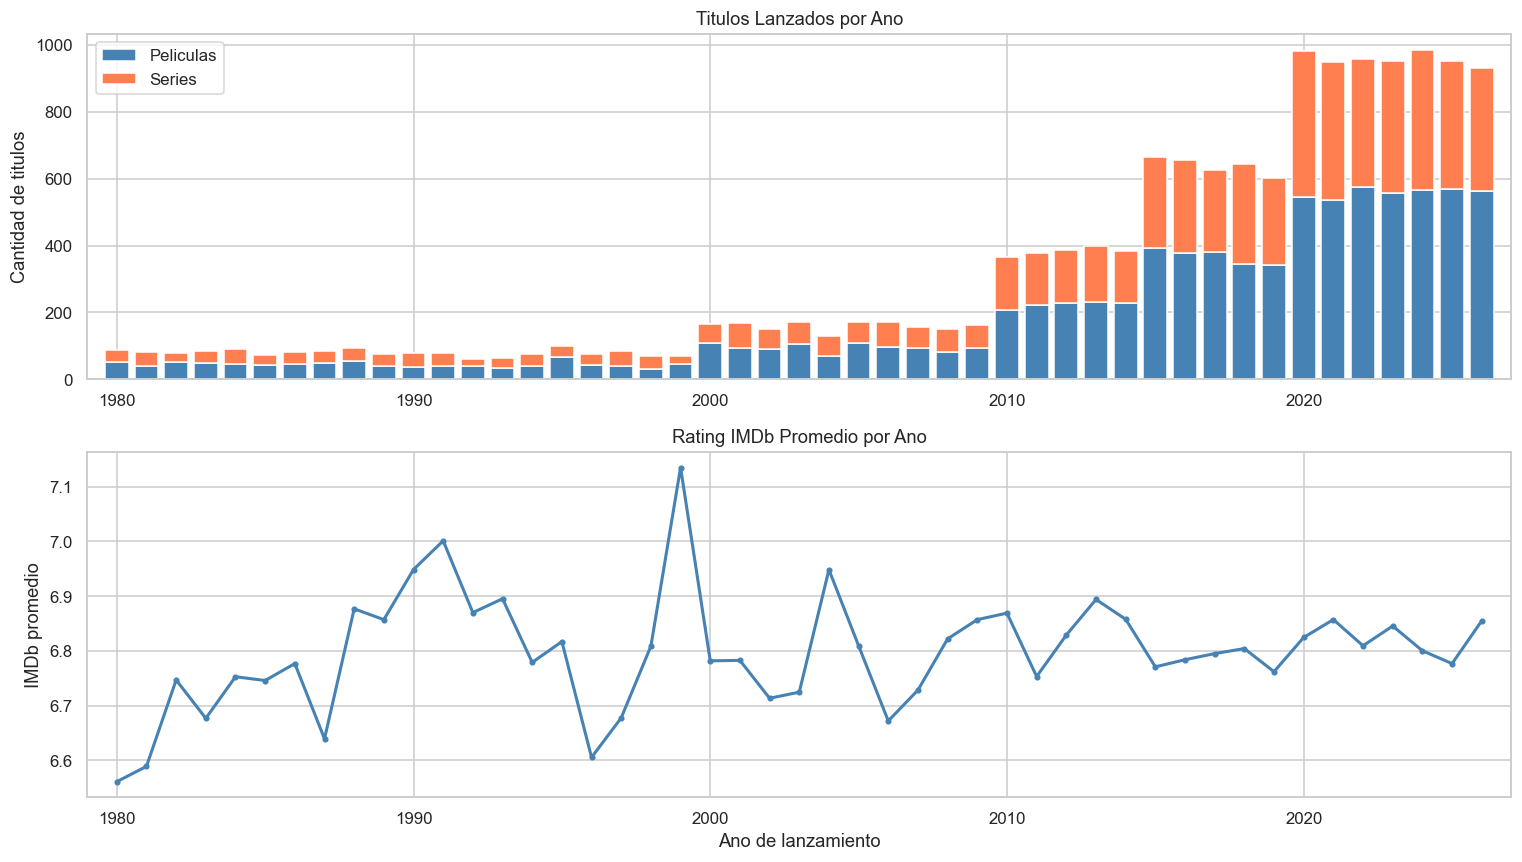

In [12]:
por_anio = df.groupby('release_year').agg(
    total     = ('show_id', 'count'),
    peliculas = ('es_pelicula', 'sum'),
    imdb_prom = ('imdb_rating', 'mean'),
)
por_anio['series'] = por_anio['total'] - por_anio['peliculas']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Lanzamientos por ano (peliculas vs series apiladas)
axes[0].bar(por_anio.index, por_anio['peliculas'], color='steelblue', label='Peliculas')
axes[0].bar(por_anio.index, por_anio['series'], bottom=por_anio['peliculas'],
            color='coral', label='Series')
axes[0].set_title('Titulos Lanzados por Ano')
axes[0].set_ylabel('Cantidad de titulos')
axes[0].set_xlim(1979, 2027)
axes[0].legend()

# IMDb promedio por ano
axes[1].plot(por_anio.index, por_anio['imdb_prom'], color='steelblue', lw=2, marker='o', ms=3)
axes[1].set_title('Rating IMDb Promedio por Ano')
axes[1].set_ylabel('IMDb promedio')
axes[1].set_xlabel('Ano de lanzamiento')
axes[1].set_xlim(1979, 2027)

plt.tight_layout()
plt.savefig(f'{FIGURAS}07_tendencia_anual.png', bbox_inches='tight')
plt.show()

## 9. Boxplots: como se distribuyen los hits vs no-hits

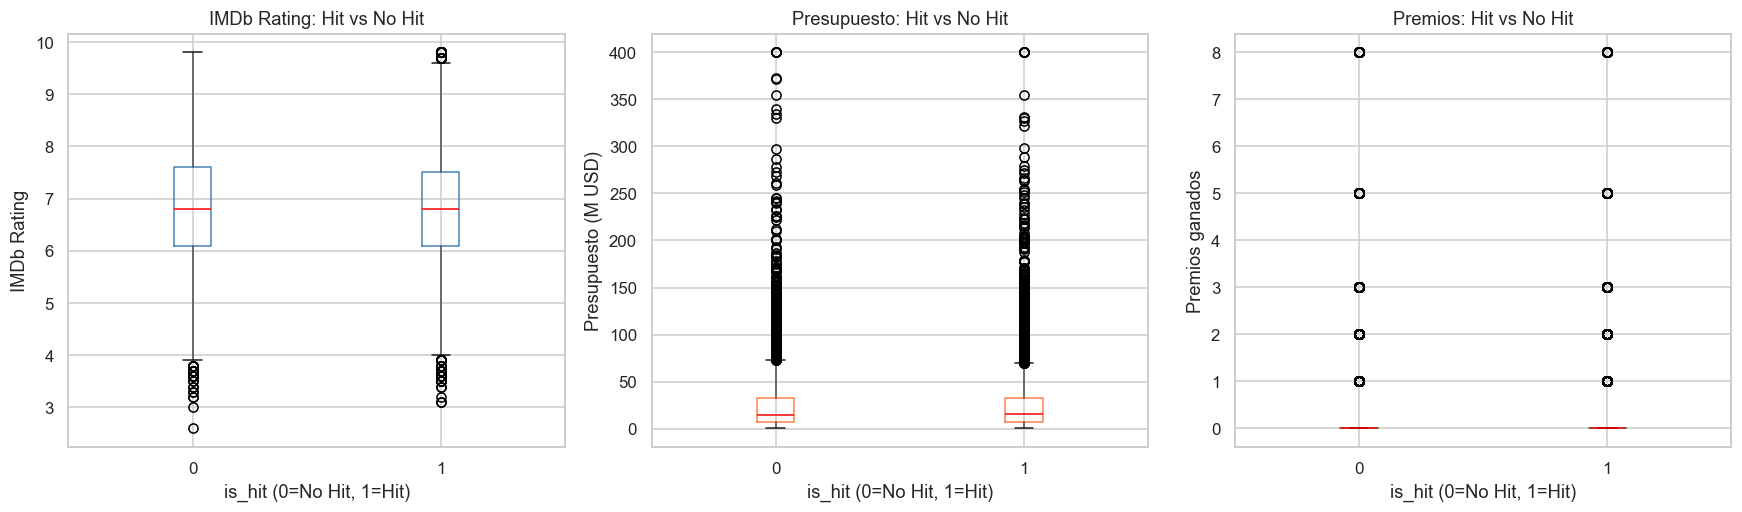

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# IMDb: hits vs no-hits
df.boxplot(column='imdb_rating', by='is_hit', ax=axes[0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[0].set_title('IMDb Rating: Hit vs No Hit')
axes[0].set_xlabel('is_hit (0=No Hit, 1=Hit)')
axes[0].set_ylabel('IMDb Rating')
plt.sca(axes[0])
plt.title('IMDb Rating: Hit vs No Hit')

# Presupuesto: hits vs no-hits (solo peliculas con presupuesto)
df_con_budget = df[df['tiene_presupuesto'] == 1]
df_con_budget.boxplot(column='budget_million_usd', by='is_hit', ax=axes[1],
                      boxprops=dict(color='coral'), medianprops=dict(color='red'))
axes[1].set_title('Presupuesto: Hit vs No Hit')
axes[1].set_xlabel('is_hit (0=No Hit, 1=Hit)')
axes[1].set_ylabel('Presupuesto (M USD)')
plt.sca(axes[1])
plt.title('Presupuesto: Hit vs No Hit')

# Premios: hits vs no-hits
df.boxplot(column='awards_won', by='is_hit', ax=axes[2],
           boxprops=dict(color='mediumseagreen'), medianprops=dict(color='red'))
axes[2].set_title('Premios: Hit vs No Hit')
axes[2].set_xlabel('is_hit (0=No Hit, 1=Hit)')
axes[2].set_ylabel('Premios ganados')
plt.sca(axes[2])
plt.title('Premios: Hit vs No Hit')

plt.suptitle('')  # elimina el titulo automatico de boxplot
plt.tight_layout()
plt.savefig(f'{FIGURAS}08_boxplots_hit.png', bbox_inches='tight')
plt.show()

## 10. Matriz de correlacion entre variables numericas

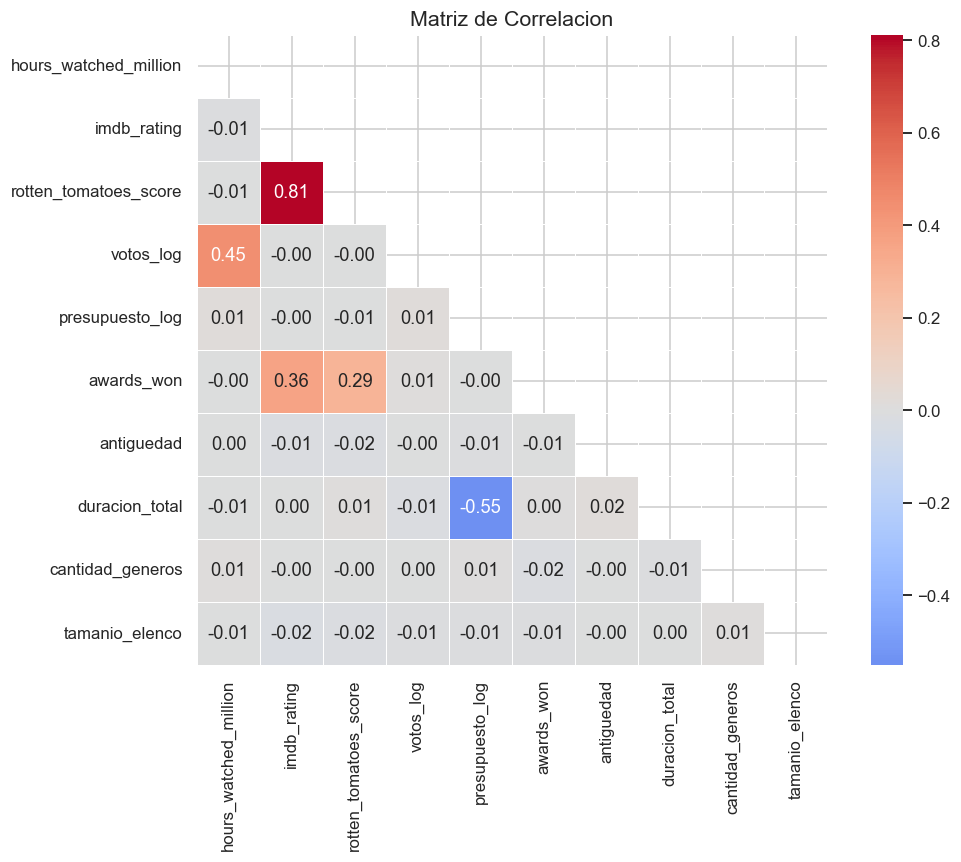

In [14]:
cols_matriz = [
    'hours_watched_million', 'imdb_rating', 'rotten_tomatoes_score',
    'votos_log', 'presupuesto_log', 'awards_won',
    'antiguedad', 'duracion_total', 'cantidad_generos', 'tamanio_elenco'
]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[cols_matriz].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # ocultar triangulo superior (redundante)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matriz de Correlacion', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURAS}09_correlacion_matriz.png', bbox_inches='tight')
plt.show()

## 11. Guardado de archivos procesados

In [15]:
# Guardamos el dataset completo con todas las features y targets
df.to_csv('../data/processed/catalogo_procesado.csv', index=False)
print('Guardado: data/processed/catalogo_procesado.csv')

# Guardamos los resumenes por plataforma, genero y pais
resumen_plat.to_csv('../data/processed/resumen_plataformas.csv')
resumen_gen.to_csv('../data/processed/resumen_generos.csv')
resumen_paises.to_csv('../data/processed/resumen_paises.csv')
print('Guardado: resumenes por plataforma, genero y pais')

print(f'\nDataset final: {df.shape[0]:,} filas, {df.shape[1]} columnas')
print(f'Figuras guardadas en: reports/figures/')

Guardado: data/processed/catalogo_procesado.csv
Guardado: resumenes por plataforma, genero y pais

Dataset final: 15,000 filas, 38 columnas
Figuras guardadas en: reports/figures/


## Resumen de hallazgos

1. **Dataset limpio**: sin duplicados, fechas en formato correcto, nulos manejados.
2. **Targets balanceados**: `is_hit` queda 50/50. `imdb_clase` queda 28/50/22.
3. **Hallazgo clave**: los votos de IMDb (`votos_log`) tienen correlacion 0.45 con las horas vistas. Es la variable mas predictiva del exito comercial.
4. **Plataformas**: Netflix domina en cantidad de titulos. La tasa de hits es similar entre plataformas, lo que indica que la plataforma sola no determina el exito.
5. **Generos**: Accion y Sci-Fi tienen la mayor tasa de hits. Documental tiene el mejor IMDb promedio.
6. **Paises**: EE.UU. produce del catalogo. Los patrones de horas vistas varian significativamente por pais.
7. **Tendencia temporal**: los lanzamientos crecen fuertemente desde 2015, con pico en 2020.